In [1]:
# Imports
!pip install -q scikit-learn opencv-python

import os
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

def compute_metrics(gt_mask, pred_mask):
    y_true = gt_mask.reshape(-1)
    y_pred = pred_mask.reshape(-1)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "iou": jaccard_score(y_true, y_pred, zero_division=0),
    }

In [ ]:
# config

DATASET_ROOT = "/content/drive/MyDrive/EWS-Dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "validation")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

RANDOM_SEED = 42
MAX_PIXELS_PER_IMAGE = 100

SVM_KERNEL = "rbf"
SVM_C = 10
SVM_GAMMA = "scale"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
feature_configs = {
    "RGB": {
        "use_hsv": False,
        "use_vegidx": False,
        "use_texture": False,
        "use_spatial": False
    },
    "RGB+HSV": {
        "use_hsv": True,
        "use_vegidx": False,
        "use_texture": False,
        "use_spatial": False
    },
    "RGB+HSV+VegIdx": {
        "use_hsv": True,
        "use_vegidx": True,
        "use_texture": False,
        "use_spatial": False
    },
    "RGB+HSV+VegIdx+Texture": {
        "use_hsv": True,
        "use_vegidx": True,
        "use_texture": True,
        "use_spatial": False
    },

}

In [4]:
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR), TRAIN_DIR)
print("VAL_DIR exists:", os.path.exists(VAL_DIR), VAL_DIR)
print("TEST_DIR exists:", os.path.exists(TEST_DIR), TEST_DIR)

print("\nSample train files:")
print(os.listdir(TRAIN_DIR)[:10])

TRAIN_DIR exists: True /content/drive/MyDrive/EWS-Dataset/train
VAL_DIR exists: True /content/drive/MyDrive/EWS-Dataset/validation
TEST_DIR exists: True /content/drive/MyDrive/EWS-Dataset/test

Sample train files:
['FPWW0220139_RGB1_20180124_121906_6.png', 'FPWW0220078_RGB1_20180411_114840_6.png', 'FPWW0220420_RGB1_20180404_133527_6_mask.png', 'FPWW0220356_RGB1_20171213_143142_6_mask.png', 'FPWW0220139_RGB1_20180124_121906_6_mask.png', 'FPWW0220078_RGB1_20180112_122034_6_mask.png', 'FPWW0220032_RGB1_20180220_142617_6.png', 'FPWW0220155_RGB1_20180207_122841_6_mask.png', 'FPWW0220032_RGB1_20180305_114520_6.png', 'FPWW0220032_RGB1_20171213_141430_6_mask.png']


In [5]:
def read_rgb_image(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {path}")
    return (mask > 127).astype(np.uint8)

def paired_paths(folder):
    files = sorted(os.listdir(folder))

    image_files = []
    for f in files:
        f_lower = f.lower()
        if f_lower.endswith(".png") and not f_lower.endswith("_mask.png"):
            image_files.append(f)

    pairs = []
    for img_name in image_files:
        base, ext = os.path.splitext(img_name)
        mask_name = base + "_mask" + ext

        img_path = os.path.join(folder, img_name)
        mask_path = os.path.join(folder, mask_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for image: {img_name}")

        pairs.append((img_path, mask_path))

    return pairs

def load_dataset(folder):
    pairs = paired_paths(folder)
    images, masks = [], []

    for img_path, mask_path in pairs:
        images.append(read_rgb_image(img_path))
        masks.append(read_mask(mask_path))

    return images, masks, pairs

In [6]:
train_images, train_masks, train_pairs = load_dataset(TRAIN_DIR)
val_images, val_masks, val_pairs = load_dataset(VAL_DIR)
test_images, test_masks, test_pairs = load_dataset(TEST_DIR)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

print("\nFirst 3 training pairs:")
for p in train_pairs[:3]:
    print(p)

Training images: 109
Validation images: 24
Test images: 24

First 3 training pairs:
('/content/drive/MyDrive/EWS-Dataset/train/FPWW0220011_RGB1_20180316_100219_6.png', '/content/drive/MyDrive/EWS-Dataset/train/FPWW0220011_RGB1_20180316_100219_6_mask.png')
('/content/drive/MyDrive/EWS-Dataset/train/FPWW0220032_RGB1_20171213_141430_6.png', '/content/drive/MyDrive/EWS-Dataset/train/FPWW0220032_RGB1_20171213_141430_6_mask.png')
('/content/drive/MyDrive/EWS-Dataset/train/FPWW0220032_RGB1_20180112_121036_6.png', '/content/drive/MyDrive/EWS-Dataset/train/FPWW0220032_RGB1_20180112_121036_6_mask.png')


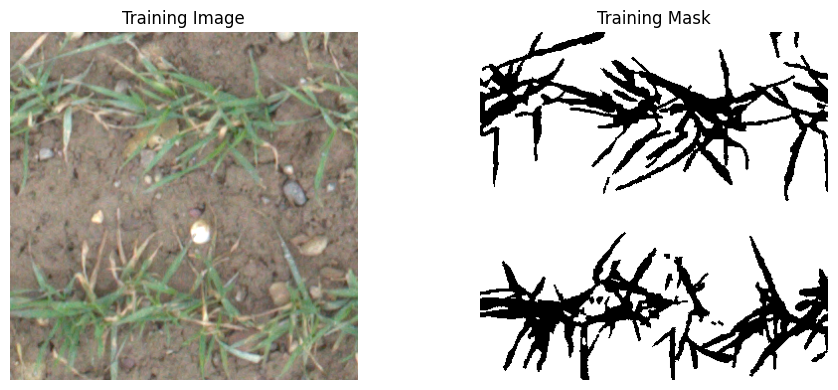

Image shape: (350, 350, 3)
Mask shape: (350, 350)
Mask unique values: [0 1]


In [7]:
idx = 0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(train_images[idx])
plt.title("Training Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(train_masks[idx], cmap="gray")
plt.title("Training Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", train_images[idx].shape)
print("Mask shape:", train_masks[idx].shape)
print("Mask unique values:", np.unique(train_masks[idx]))

In [8]:
def local_variance(gray, ksize=5):
    gray_f = gray.astype(np.float32)
    mean = cv2.blur(gray_f, (ksize, ksize))
    mean_sq = cv2.blur(gray_f * gray_f, (ksize, ksize))
    return mean_sq - mean * mean


def extract_features(
    image,
    use_hsv=False,
    use_vegidx=False,
    use_texture=False,
    use_spatial=False
):
    rgb = image.astype(np.float32) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    feature_list = [r, g, b]

    hsv = None
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    if use_hsv:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
        h = hsv[:, :, 0] / 179.0
        s = hsv[:, :, 1] / 255.0
        v = hsv[:, :, 2] / 255.0
        feature_list.extend([h, s, v])

    if use_vegidx:
        exg = 2 * g - r - b
        ngrdi = (g - r) / (g + r + 1e-6)
        feature_list.extend([exg, ngrdi])

    if use_texture:
        var5 = local_variance((gray * 255).astype(np.uint8), ksize=5)
        var5 = var5 / (np.max(var5) + 1e-6)
        feature_list.extend([gray, var5])

    if use_spatial:
        H, W = gray.shape
        yy, xx = np.meshgrid(
            np.arange(H, dtype=np.float32) / max(H - 1, 1),
            np.arange(W, dtype=np.float32) / max(W - 1, 1),
            indexing="ij"
        )
        feature_list.extend([xx, yy])

    return np.stack(feature_list, axis=-1).astype(np.float32)

In [9]:
def sample_pixels_from_image(
    image,
    mask,
    max_pixels=3000,
    use_hsv=False,
    use_vegidx=False,
    use_texture=False,
    use_spatial=False
):
    feat = extract_features(
        image,
        use_hsv=use_hsv,
        use_vegidx=use_vegidx,
        use_texture=use_texture,
        use_spatial=use_spatial
    )

    X = feat.reshape(-1, feat.shape[-1])
    y = mask.reshape(-1)

    n = len(y)
    if n <= max_pixels:
        idx = np.arange(n)
    else:
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]

        n_pos = min(len(pos_idx), max_pixels // 2)
        n_neg = min(len(neg_idx), max_pixels - n_pos)

        pos_sample = np.random.choice(pos_idx, size=n_pos, replace=False) if n_pos > 0 else np.array([], dtype=int)
        neg_sample = np.random.choice(neg_idx, size=n_neg, replace=False) if n_neg > 0 else np.array([], dtype=int)

        idx = np.concatenate([pos_sample, neg_sample])

        if len(idx) < max_pixels:
            remain = np.setdiff1d(np.arange(n), idx, assume_unique=False)
            extra_needed = min(max_pixels - len(idx), len(remain))
            if extra_needed > 0:
                extra = np.random.choice(remain, size=extra_needed, replace=False)
                idx = np.concatenate([idx, extra])

    np.random.shuffle(idx)
    return X[idx], y[idx]


In [10]:
def build_training_set(
    images,
    masks,
    max_pixels_per_image=3000,
    use_hsv=False,
    use_vegidx=False,
    use_texture=False,
    use_spatial=False
):
    X_list, y_list = [], []

    for image, mask in zip(images, masks):
        X_i, y_i = sample_pixels_from_image(
            image,
            mask,
            max_pixels=max_pixels_per_image,
            use_hsv=use_hsv,
            use_vegidx=use_vegidx,
            use_texture=use_texture,
            use_spatial=use_spatial
        )
        X_list.append(X_i)
        y_list.append(y_i)

    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

In [11]:
X_train, y_train = build_training_set(
    train_images,
    train_masks,
    max_pixels_per_image=MAX_PIXELS_PER_IMAGE
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Positive class ratio:", y_train.mean())

X_train shape: (10900, 3)
y_train shape: (10900,)
Positive class ratio: 0.5


In [12]:
def train_svm(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = SVC(
        kernel=SVM_KERNEL,
        C=SVM_C,
        gamma=SVM_GAMMA,
        class_weight="balanced",
        verbose=True
    )

    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    return model, scaler, train_time

model, scaler, train_time = train_svm(X_train, y_train)
print(f"Training completed in {train_time:.2f} seconds")

[LibSVM]Training completed in 6.06 seconds


In [13]:
def predict_mask(
    model,
    scaler,
    image,
    use_hsv=False,
    use_vegidx=False,
    use_texture=False,
    use_spatial=False
):
    feat = extract_features(
        image,
        use_hsv=use_hsv,
        use_vegidx=use_vegidx,
        use_texture=use_texture,
        use_spatial=use_spatial
    )

    H, W, D = feat.shape
    X = feat.reshape(-1, D)
    X_scaled = scaler.transform(X)

    start = time.time()
    pred = model.predict(X_scaled)
    infer_time = time.time() - start

    return pred.reshape(H, W).astype(np.uint8), infer_time

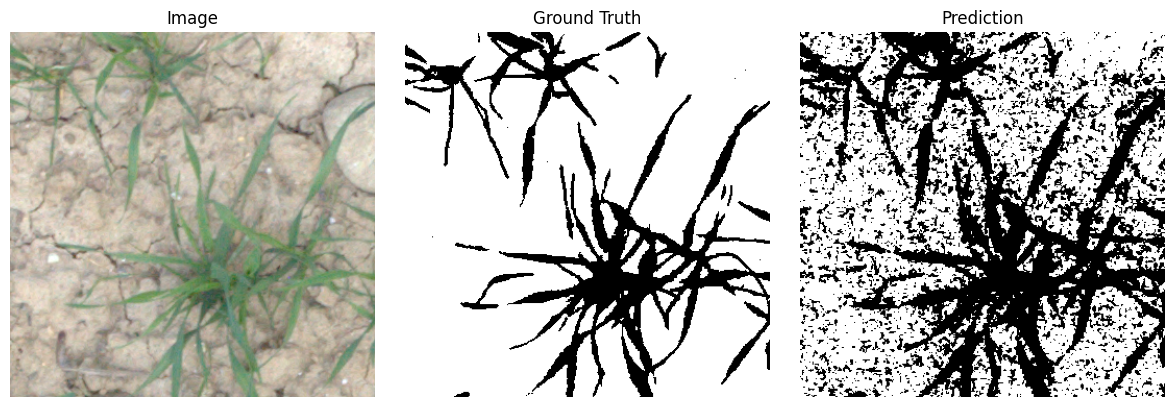

Inference time: 38.0335168838501
{'accuracy': 0.7534775510204081, 'precision': 0.9931006899310069, 'recall': 0.7005642885933091, 'f1': 0.8215684768415393, 'iou': np.float64(0.6971711641246252)}


In [14]:
idx = 0
pred_mask, infer_time = predict_mask(model, scaler, val_images[idx])
metrics = compute_metrics(val_masks[idx], pred_mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(val_images[idx])
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(val_masks[idx], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Inference time:", infer_time)
print(metrics)

In [ ]:
def evaluate_dataset(
    model,
    scaler,
    images,
    masks,
    use_hsv=False,
    use_vegidx=False,
    use_texture=False,
    use_spatial=False,
    return_per_image=False
):
    all_metrics = []
    all_times = []
    per_image_results = []

    for idx, (image, gt_mask) in enumerate(zip(images, masks)):
        pred_mask, infer_time = predict_mask(
            model,
            scaler,
            image,
            use_hsv=use_hsv,
            use_vegidx=use_vegidx,
            use_texture=use_texture,
            use_spatial=use_spatial
        )

        metrics = compute_metrics(gt_mask, pred_mask)
        all_metrics.append(metrics)
        all_times.append(infer_time)

        if return_per_image:
            per_image_results.append({
                "index": idx,
                "metrics": metrics,
                "infer_time_sec": infer_time,
                "image": image,
                "gt_mask": gt_mask,
                "pred_mask": pred_mask
            })

    avg = {}
    for key in all_metrics[0]:
        avg[key] = float(np.mean([m[key] for m in all_metrics]))

    avg["avg_inference_time_per_image_sec"] = float(np.mean(all_times))

    if return_per_image:
        return avg, per_image_results
    return avg

In [ ]:
# evaluate the different configs

import pandas as pd

SVM_C = 5
SVM_GAMMA = "scale"
MAX_PIXELS_PER_IMAGE = 100

all_results = []

for config_name, cfg in feature_configs.items():
    print("\n" + "=" * 60)
    print(f"Running config: {config_name}")
    print("=" * 60)

    X_train, y_train = build_training_set(
        train_images,
        train_masks,
        max_pixels_per_image=MAX_PIXELS_PER_IMAGE,
        **cfg
    )

    print("Training set shape:", X_train.shape)

    model, scaler, train_time = train_svm(X_train, y_train)

    val_results = evaluate_dataset(
        model,
        scaler,
        val_images,
        val_masks,
        **cfg
    )

    val_results["config"] = config_name
    val_results["train_time_sec"] = train_time
    val_results["pixels_per_image"] = MAX_PIXELS_PER_IMAGE
    val_results["C"] = SVM_C
    val_results["gamma"] = SVM_GAMMA

    all_results.append(val_results)

results_df = pd.DataFrame(all_results)
results_df = results_df[
    [
        "config",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "iou",
        "avg_inference_time_per_image_sec",
        "train_time_sec",
        "pixels_per_image",
        "C",
        "gamma"
    ]
]

results_df.sort_values("iou", ascending=False)


Running config: RGB
Training set shape: (10900, 3)
[LibSVM]
Running config: RGB+HSV
Training set shape: (10900, 6)
[LibSVM]
Running config: RGB+HSV+VegIdx
Training set shape: (10900, 8)
[LibSVM]
Running config: RGB+HSV+VegIdx+Texture
Training set shape: (10900, 10)
[LibSVM]

,config,accuracy,precision,recall,f1,iou,avg_inference_time_per_image_sec,train_time_sec,pixels_per_image,C,gamma
0,RGB,0.897862,0.944519,0.864774,0.897881,0.821922,26.609931,3.442041,100,5,scale
3,RGB+HSV+VegIdx+Texture,0.884526,0.934260,0.854473,0.886279,0.804076,30.068485,3.439191,100,5,scale
1,RGB+HSV,0.886624,0.947805,0.839799,0.883731,0.801093,27.491569,4.303751,100,5,scale
2,RGB+HSV+VegIdx,0.878511,0.954474,0.819668,0.874577,0.789417,28.410150,3.648590,100,5,scale


In [ ]:
#Rerun best model - RGB only

config = "RGB"

X_train, y_train = build_training_set(
    train_images,
    train_masks,
    max_pixels_per_image=100,
)

model, scaler, _ = train_svm(X_train, y_train)

[LibSVM]

Best IoU: 0.9734266426710894 at index 17
Worst IoU: 0.5755372126260245 at index 13


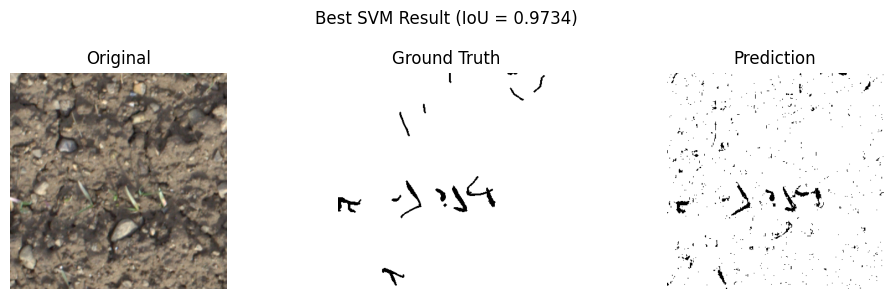

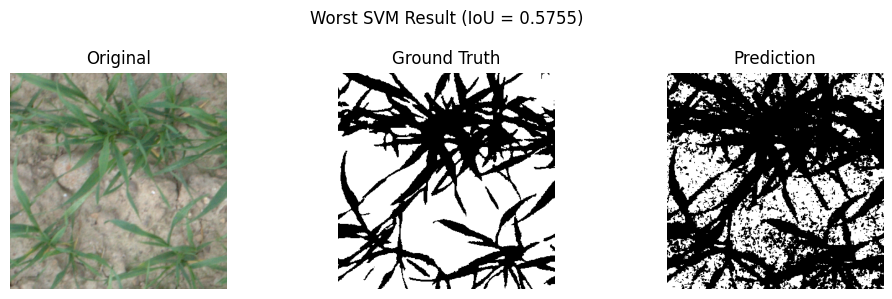

In [ ]:
# get best and worst case

import numpy as np
import matplotlib.pyplot as plt

def compute_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / (union + 1e-6)

ious = []
preds = []

for i in range(len(test_images)):
    pred_mask, _ = predict_mask(model, scaler, test_images[i])
    preds.append(pred_mask)
    ious.append(compute_iou(test_masks[i], pred_mask))

ious = np.array(ious)

best_idx = np.argmax(ious)
worst_idx = np.argmin(ious)

print("Best IoU:", ious[best_idx], "at index", best_idx)
print("Worst IoU:", ious[worst_idx], "at index", worst_idx)

def save_example(idx, filename, title):
    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(test_images[idx])
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(test_masks[idx], cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(preds[idx], cmap="gray")
    plt.axis("off")

    plt.suptitle(f"{title} (IoU = {ious[idx]:.4f})")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

save_example(best_idx, "svm_best.png", "Best SVM Result")
save_example(worst_idx, "svm_worst.png", "Worst SVM Result")